# Exploratory Data Analysis (EDA): Laptop Market Pricing & Volume (2015-2025)
This notebook performs a visual and statistical analysis of our 10-year laptop dataset (Dell, HP, Lenovo, Asus). 
It covers:
1. **Price Trends**: Average Selling Price (ASP) changes and inflation over the last decade.
2. **Sales Volumes**: Volume growth and promotional dips/spikes.
3. **Seasonality Analysis**: Back-to-School and Festive sales cycles.
4. **Price Elasticity (Visual)**: The relationship between price changes and demand shifts.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Set style for charts
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# Load dataset
df = pd.read_csv("laptop_pricing_data.csv")
df['date'] = pd.to_datetime(df['date'])
print(f"Loaded dataset with {len(df)} rows.")
print("Columns:", list(df.columns))
df.head()

Loaded dataset with 2192 rows.
Columns: ['date', 'brand', 'sku_id', 'unit_price', 'units_sold', 'cost_per_unit', 'is_promo', 'is_festival', 'comp_price_1', 'comp_price_2', 'comp_price_3']


,date,brand,sku_id,unit_price,units_sold,cost_per_unit,is_promo,is_festival,comp_price_1,comp_price_2,comp_price_3
0,2015-01-03,Dell,LAPTOP_DELL_SERIES,43276.25,51913.1,32040.0,0,1,40845.00,37441.25,35010.00
1,2015-01-03,HP,LAPTOP_HP_SERIES,40845.00,63036.1,31080.0,0,1,43276.25,37441.25,35010.00
2,2015-01-03,Lenovo,LAPTOP_LENOVO_SERIES,34445.95,61136.2,29260.0,1,1,43276.25,40845.00,35010.00
3,2015-01-03,Asus,LAPTOP_ASUS_SERIES,32209.20,18147.7,28080.0,1,1,43276.25,40845.00,37441.25
4,2015-01-10,Dell,LAPTOP_DELL_SERIES,43276.25,49768.7,32040.0,0,1,40845.00,37441.25,35010.00


In [2]:
# Summary Statistics by Brand
print("--- SUMMARY STATISTICS ---")
summary = df.groupby("brand").agg({
    "unit_price": ["min", "mean", "max", "std"],
    "units_sold": ["min", "mean", "max", "sum"],
    "cost_per_unit": ["min", "mean", "max"]
})
print(summary)

--- SUMMARY STATISTICS ---
       unit_price                                      units_sold  \
              min          mean       max          std        min   
brand                                                               
Asus     32209.20  46927.180036  61346.25  8125.423817     7231.1   
Dell     39814.15  56209.898650  71820.00  8942.413665    31434.1   
HP       38651.04  53010.152391  67830.00  8318.722720    39281.2   
Lenovo   34445.95  49392.558157  63840.00  8170.515864    24038.6   

                                           cost_per_unit                \
                mean       max         sum           min          mean   
brand                                                                    
Asus    17882.947445   41068.0   9799855.2       28080.0  37210.270073   
Dell    53975.772628  126006.2  29578723.4       32040.0  41071.270073   
HP      82068.217336  176563.5  44973383.1       31080.0  39865.609489   
Lenovo  55112.518248  122946.7  30201660.0   

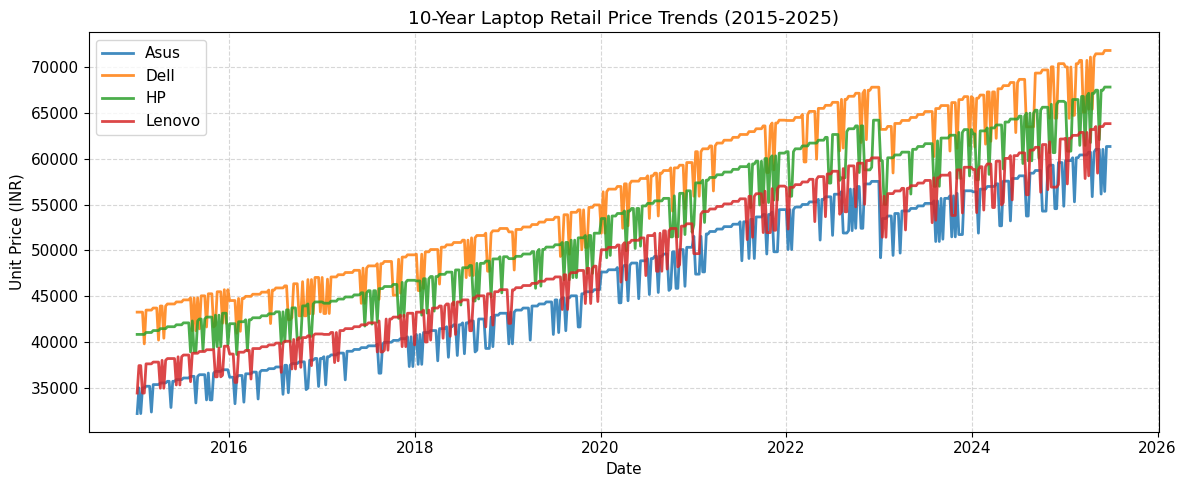

In [3]:
# 1. Retail Price Trends (2015 - 2025)
plt.figure(figsize=(12, 5))
for brand, bdf in df.groupby('brand'):
    plt.plot(bdf['date'], bdf['unit_price'], label=brand, linewidth=2, alpha=0.85)
plt.title("10-Year Laptop Retail Price Trends (2015-2025)")
plt.xlabel("Date")
plt.ylabel("Unit Price (INR)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

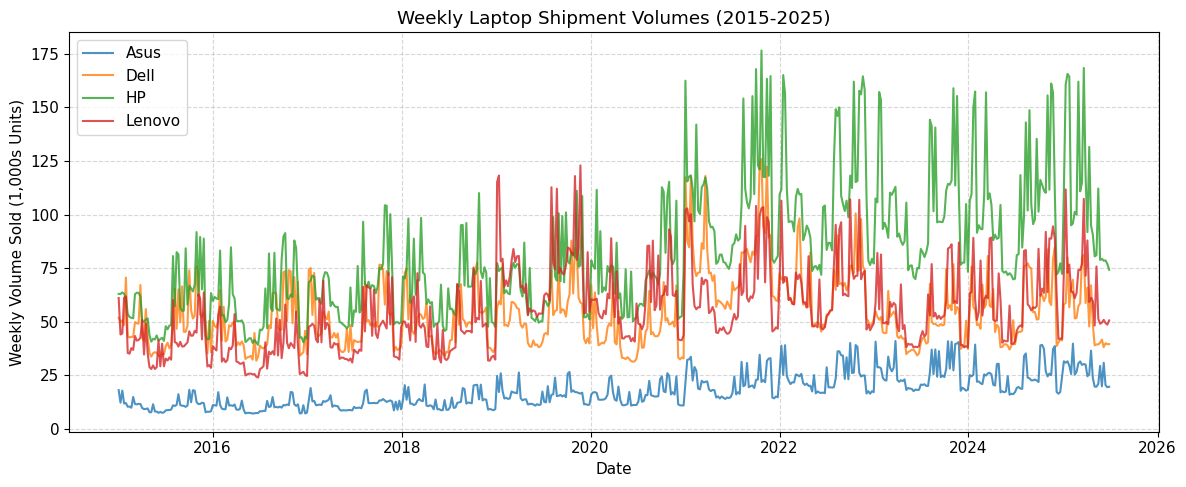

In [4]:
# 2. Sales Demand Volumes (2015 - 2025)
plt.figure(figsize=(12, 5))
for brand, bdf in df.groupby('brand'):
    plt.plot(bdf['date'], bdf['units_sold'] / 1e3, label=brand, linewidth=1.5, alpha=0.8)
plt.title("Weekly Laptop Shipment Volumes (2015-2025)")
plt.xlabel("Date")
plt.ylabel("Weekly Volume Sold (1,000s Units)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

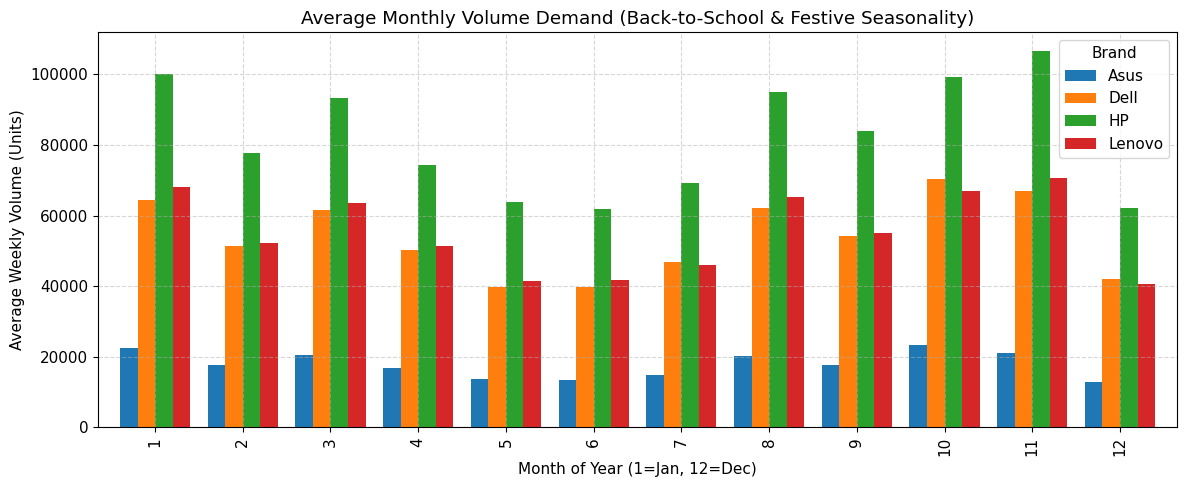

In [5]:
# 3. Monthly Demand Seasonality
df['month'] = df['date'].dt.month
monthly_sales = df.groupby(['month', 'brand'])['units_sold'].mean().unstack()

plt.figure(figsize=(12, 5))
monthly_sales.plot(kind='bar', figsize=(12, 5), width=0.8)
plt.title("Average Monthly Volume Demand (Back-to-School & Festive Seasonality)")
plt.xlabel("Month of Year (1=Jan, 12=Dec)")
plt.ylabel("Average Weekly Volume (Units)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Brand")
plt.tight_layout()
plt.show()

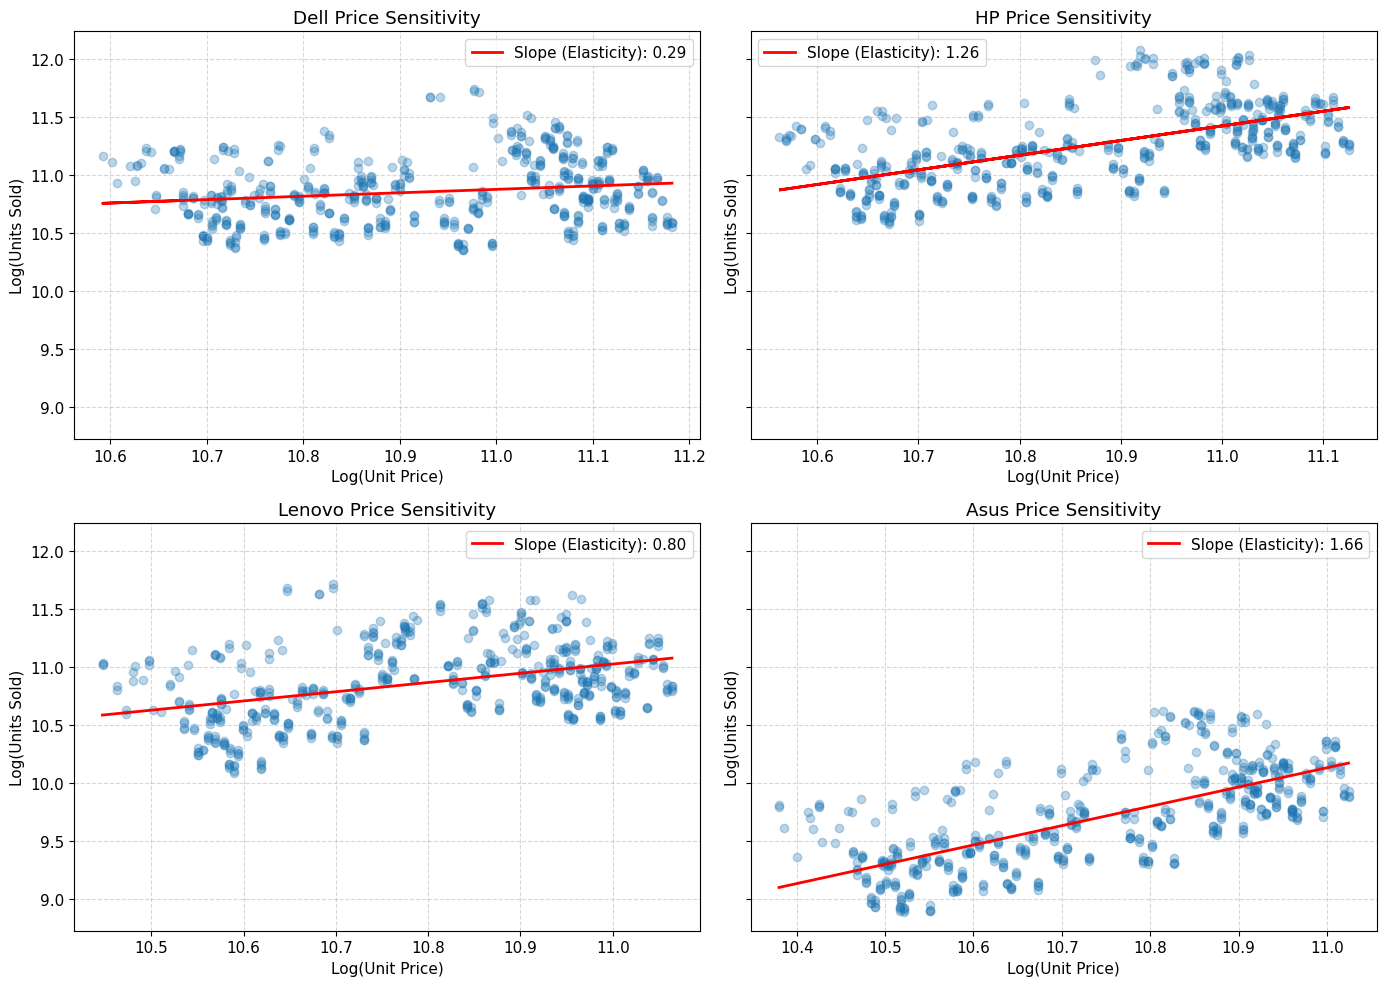

In [6]:
# 4. Log-Log Price vs Quantity Regression Lines (Elasticity Visual)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

brands = df['brand'].unique()
for idx, brand in enumerate(brands):
    bdf = df[df['brand'] == brand]
    log_p = np.log(bdf['unit_price'])
    log_q = np.log(bdf['units_sold'])
    
    axes[idx].scatter(log_p, log_q, alpha=0.3, color='tab:blue')
    
    # Fit line
    m, b = np.polyfit(log_p, log_q, 1)
    axes[idx].plot(log_p, m*log_p + b, color='red', linewidth=2, label=f"Slope (Elasticity): {m:.2f}")
    
    axes[idx].set_title(f"{brand} Price Sensitivity")
    axes[idx].set_xlabel("Log(Unit Price)")
    axes[idx].set_ylabel("Log(Units Sold)")
    axes[idx].grid(True, linestyle='--', alpha=0.5)
    axes[idx].legend()

plt.tight_layout()
plt.show()